# Bone Age Prediction

This notebook presents a pipeline for training two VGG-style convolutional neural networks (CNNs) to predict the age of the children based on X-ray images of their hand.

This project was completed as part of the course ELEC-E8739 - AI in Health Technologies at Aalto University together with Juho Karhu and Niko Somila. 

The dataset used for this project is from the [RSNA Bone Age competition on Kaggle](https://www.kaggle.com/datasets/kmader/rsna-bone-age/data).

The project begins with importing libraries, activating the GPU, and mounting Google Drive. Data is split into training, validation, and test sets using train_test_split. Bone age distributions and X-ray images are examined. Two models are used: a standard VGG and an improved VGG. The create_vgg_model() function builds the model, weights are loaded from Drive, and training is done with train_model(). After training, the loss function is plotted, and performance is compared using bootstrapping and key metrics.

## Initialization

This section contains code to load necessary libraries, activate the GPU, and mount Google Drive to access the dataset. 

In [ ]:
# Import librarys

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from sklearn.model_selection import train_test_split
import os
import tensorflow as tf
import cv2
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from keras.optimizers import Adam
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle

In [ ]:
# Use GPUs if available

gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    try:
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')  # Use the first GPU
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPU")
    except RuntimeError as e:
        print(e)
tf.test.gpu_device_name()

1 Physical GPUs, 1 Logical GPU


'/device:GPU:0'

The data is stored in a Google drive folder:
Permissions needs to be added to access the folder.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Data preprocessing

The following code blocks contain functions essential for loading, preprocessing, and visualizing the dataset.

### Load data from drive and combine to one dataset:


In [ ]:
# Opening csv file
training_dataset = pd.read_csv("/content/drive/MyDrive/AI_project/AI_data/boneage-training-dataset.csv")
training_dataset.head()

,id,boneage,male
0,1377,180,False
1,1378,12,False
2,1379,94,False
3,1380,120,True
4,1381,82,False


In [ ]:
#Adding a path to an image. Also let's add an extension.
training_dataset['image_path'] = "/content/drive/MyDrive/AI_project/AI_data/boneage-training-dataset/boneage-training-dataset/" + training_dataset['id'].astype(str) + ".png"
training_dataset.head()

,id,boneage,male,image_path
0,1377,180,False,/content/drive/MyDrive/AI_project/AI_data/bone...
1,1378,12,False,/content/drive/MyDrive/AI_project/AI_data/bone...
2,1379,94,False,/content/drive/MyDrive/AI_project/AI_data/bone...
3,1380,120,True,/content/drive/MyDrive/AI_project/AI_data/bone...
4,1381,82,False,/content/drive/MyDrive/AI_project/AI_data/bone...


In [ ]:
print("Boneages ranging from: ", np.min(training_dataset['boneage']), " to ", np.max(training_dataset['boneage']))
boys_dataset= training_dataset[training_dataset['male']==True]
print("In total:", len(training_dataset) ,"images and which of", len(boys_dataset), "were Boys:")


Boneages ranging from:  1  to  228
In total: 12611 images and which of 6833 were Boys:


### Split the full dataset into training, validation and testing datasets using function train_test_split from sklearn.model.

In [ ]:
df_train, df_test = train_test_split(training_dataset, test_size=0.3, random_state=42, shuffle = True)
df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=42, shuffle = True)


### Functions used to visualize the data:

In [ ]:
def plot_boneage_histograms(train, full_dataset):
  fig, ax = plt.subplots(ncols=2, figsize=(10,5))
  sns.set_style('whitegrid')
  sns.set_palette('inferno')
  sns.distplot(full_dataset['boneage'], rug=True, kde_kws={'shade':True, 'color':'r'}, ax=ax[0])
  ax[0].set_xlabel('Age', fontsize=12, color='b')
  ax[0].set_ylabel('Frequency', fontsize=12, color='b')
  ax[0].set_title('Boneage distribution in full dataset', fontsize=13, color='b')

  sns.distplot(train['boneage'], rug=True, kde_kws={'shade':True, 'color':'r'}, ax=ax[1])
  ax[1].set_xlabel('Age', fontsize=12, color='b')
  ax[1].set_ylabel('Frequency', fontsize=12, color='b')
  ax[1].set_title('Boneage distribution in training dataset', fontsize=13, color='b')

  plt.show()
  fig.savefig('/content/drive/MyDrive/AI_project/Models/histrograms.png')


In [ ]:
def plotting(data_path,n_rows=2,n_cols=2):
    print(data_path[0])
    fig,axes=plt.subplots(n_rows,n_cols*2,layout="tight",figsize=(15,15))
    axes=axes.flatten()

    for ind,ax in enumerate(axes):
        th=np.random.randint(len(data_path))
        img=cv2.imread(data_path[th])
        if img is not None:  # Check if the image was successfully loaded


                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Display grayscale image
        else:
            print(f"Failed to load image: {data_path[th]}")
    fig.savefig('/content/drive/MyDrive/AI_project/Models/images.png')

<ipython-input-9-8bb673e4cc2b>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(full_dataset['boneage'], rug=True, kde_kws={'shade':True, 'color':'r'}, ax=ax[0])
/usr/local/lib/python3.10/dist-packages/seaborn/distributions.py:2511: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
<ipython-input-9-8bb673e4cc2b>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function wi

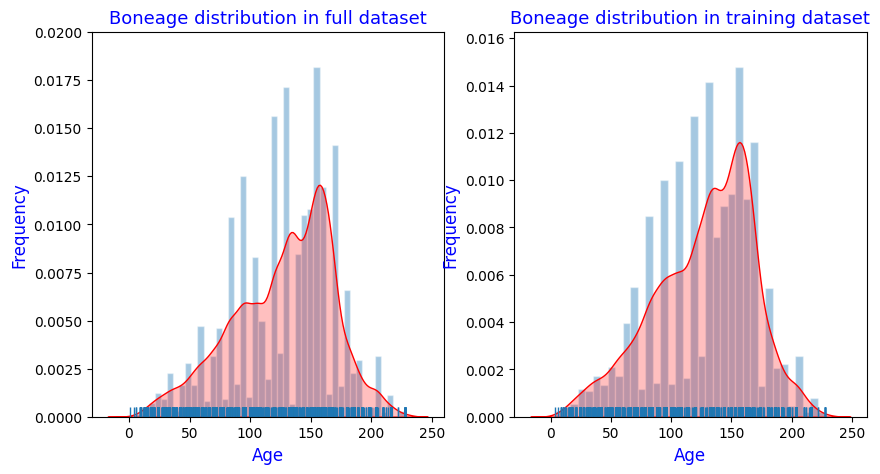

In [ ]:
plot_boneage_histograms(df_train, training_dataset)

/content/drive/MyDrive/AI_project/AI_data/boneage-training-dataset/boneage-training-dataset/8270.png


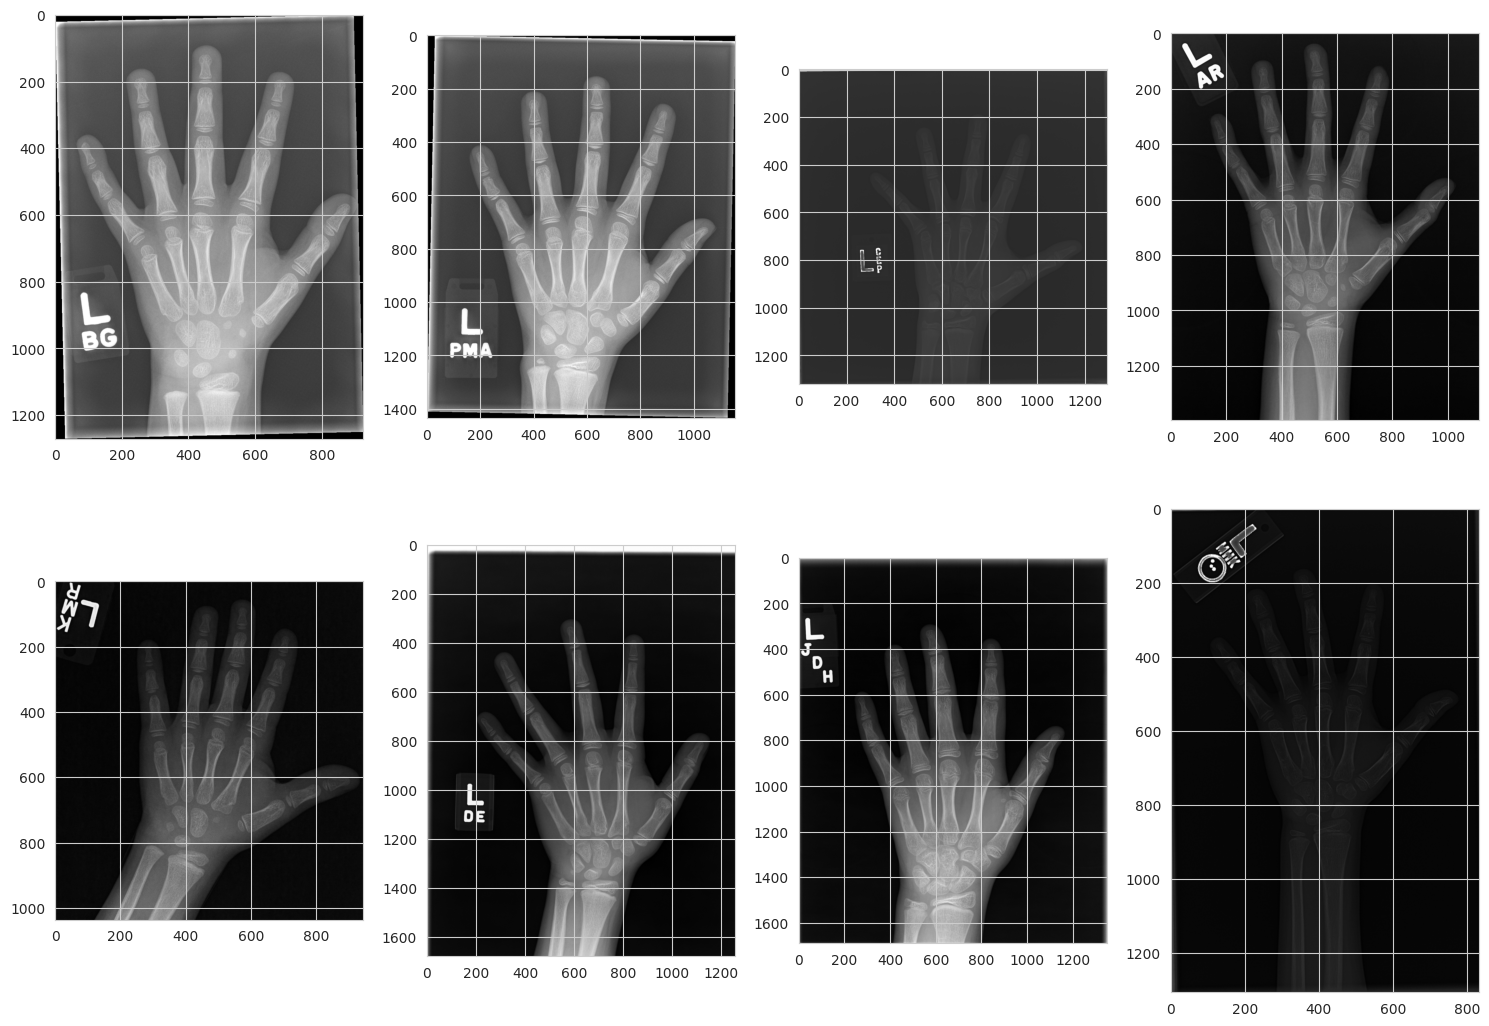

In [ ]:
plotting(df_train['image_path'].tolist())


Example how the prerpocessed images look like:

Found 7061 validated image filenames.


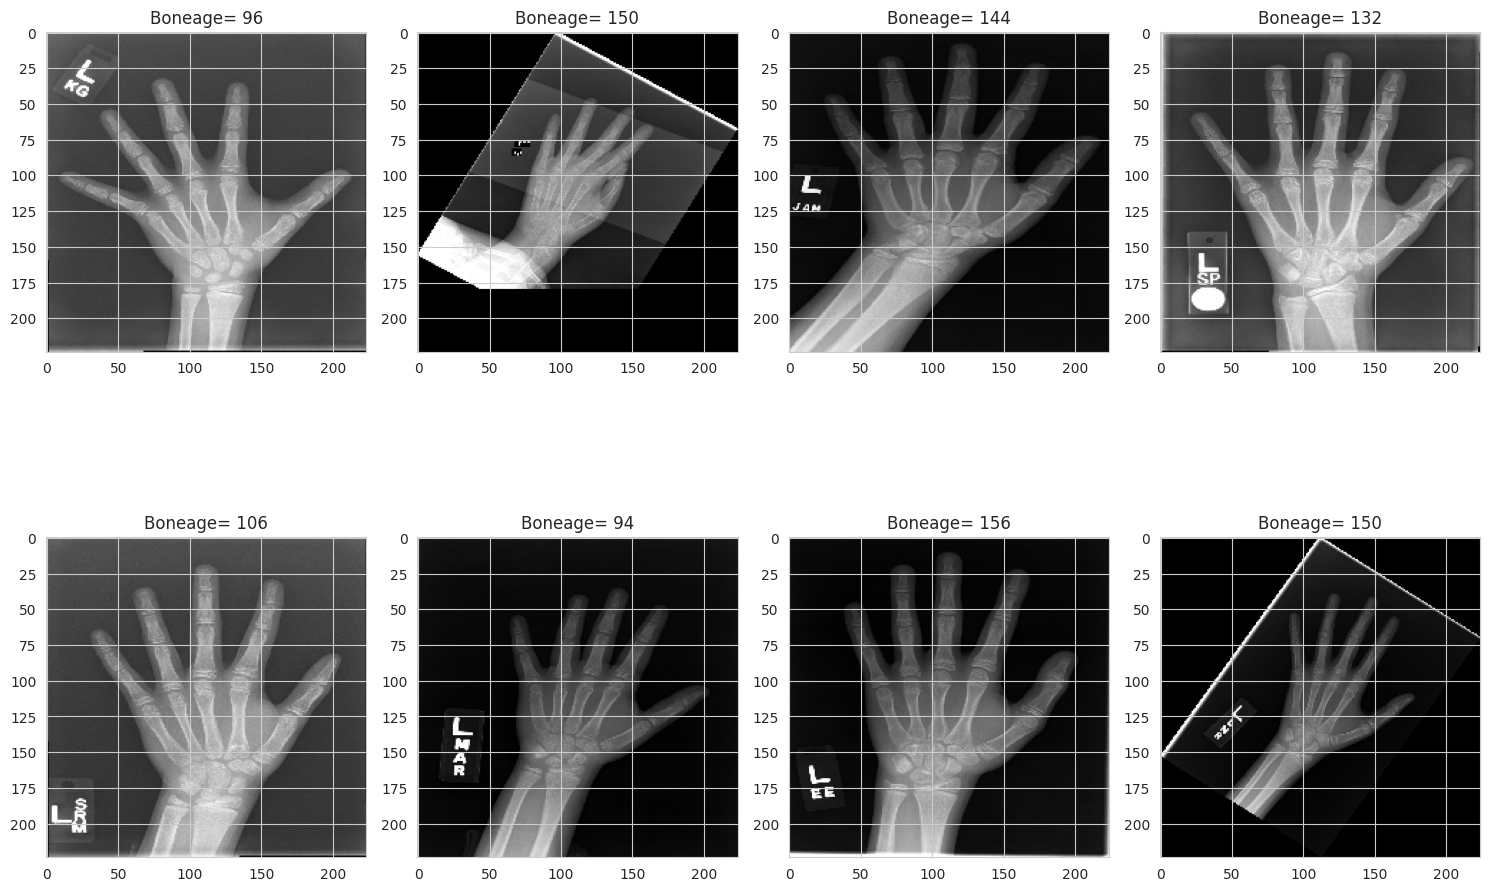

In [ ]:
train_gen = ImageDataGenerator(rescale = 1./255)
training= train_gen.flow_from_dataframe(dataframe=df_train,
                                            x_col='image_path', y_col='boneage', class_mode='raw', target_size=(224,224), batch_size=32, color_mode = 'rgb')
images, labels= next(training)

fig,ax=plt.subplots(2,4,layout="tight",figsize=(15,15))
row=0
j=0
for i, (image, label) in enumerate(zip(images, labels)):

  if i < 8:
    if (j==4):
      row+=1
      j=0
    ax[row,j].imshow(image.squeeze())
    ax[row,j].set_title('Boneage= {}'.format(label))
    j+=1
  else:
    break
#fig.savefig('/content/drive/MyDrive/AI_project/Models/processed_images.png')

### Functions to preprocess the data:

Convert datasets into dataloaders using Tensorflow function ImageDataGenerator. In addition, all images are scaled.

In [ ]:
def datagenerators(baseline):
  if baseline:
    train_gen = ImageDataGenerator(rescale = 1./255)
    val_gen = ImageDataGenerator(rescale = 1./255)
    test_gen = ImageDataGenerator(rescale = 1./255)
  else:
    train_gen = ImageDataGenerator(rescale = 1./255, rotation_range=20, zoom_range=0.15,
                           width_shift_range=0.2, height_shift_range=0.2, shear_range=0.15,
                           horizontal_flip=True, vertical_flip = False, fill_mode="nearest")
    val_gen = ImageDataGenerator(rescale = 1./255)
    test_gen = ImageDataGenerator(rescale = 1./255)

  return train_gen, val_gen, test_gen

In [ ]:
def dataloaders(baseline, train, val, test, train_gen, val_gen, test_gen ):
  if baseline:
    training_images =train_gen.flow_from_dataframe(dataframe=train,
                                            x_col='image_path', y_col='boneage', class_mode='raw', target_size=(224,224), batch_size=32, color_mode = 'rgb')
    val_images=val_gen.flow_from_dataframe(dataframe=val, directory=None,
                                            x_col='image_path', y_col="boneage", class_mode='raw', target_size=(224,224), batch_size=32, color_mode = 'rgb')
    test_images=test_gen.flow_from_dataframe(dataframe=test, directory=None,

                                             x_col='image_path', y_col="boneage", class_mode='raw', target_size=(224,224), batch_size=32, color_mode = 'rgb')

    pred_images=test_gen.flow_from_dataframe(dataframe=test, directory=None,
                                            x_col='image_path', y_col="boneage", class_mode=None, target_size=(224,224), batch_size=32, color_mode = 'rgb')

  else:

    training_images =train_gen.flow_from_dataframe(dataframe=train,
                                            x_col='image_path', y_col='boneage', class_mode='raw', target_size=(224,224), batch_size=32, color_mode = 'rgb')
    val_images=val_gen.flow_from_dataframe(dataframe=val, directory=None,
                                            x_col='image_path', y_col="boneage", class_mode='raw', target_size=(224,224), batch_size=32, color_mode = 'rgb')
    test_images=test_gen.flow_from_dataframe(dataframe=test, directory=None,
                                            x_col='image_path', y_col="boneage", class_mode='raw', target_size=(224,224), batch_size=32, color_mode = 'rgb')
    pred_images=test_gen.flow_from_dataframe(dataframe=test, directory=None,
                                            x_col='image_path', y_col="boneage", class_mode=None, target_size=(224,224), batch_size=32, color_mode = 'rgb')

  return training_images, val_images, test_images,pred_images

### Functions used while training the models:

In [ ]:
def create_mae_figure(history_data):
  fig, ax = plt.subplots(figsize = (10,6))
  x = np.arange(len(history_data))
  ax.plot(x, history_data['mae'])
  ax.plot(x, history_data['val_mae'])
  plt.title('Model absolute error (mae)')
  plt.ylabel('Mean absolute error')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper right')
  ax.grid(color='black')
  plt.show()
  return fig

In [ ]:
def create_mse_figure(history_data):
  fig, ax = plt.subplots(figsize = (10,6))
  x = np.arange(len(history_data))
  ax.plot(x, history_data['loss'])
  ax.plot(x, history_data['val_loss'])
  plt.title('Model squared error (mse)')
  plt.ylabel('Mean squared error')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper right')
  ax.grid(color='black')
  plt.show()
  return fig

In [ ]:
def train_model(model, train_data, val_data, baseline, epochs=35):
  if baseline:
    checkpoint_filepath = '/content/drive/MyDrive/AI_project/Models/vgg_baseline_2.h5'
    log_file_path = '/content/drive/MyDrive/AI_project/Models/vgg_baseline_log_2.csv'
  else:
    checkpoint_filepath = '/content/drive/MyDrive/AI_project/Models/vgg_improved_2.h5'
    log_file_path = '/content/drive/MyDrive/AI_project/Models/vgg_improved_log_2.csv'
 # if os.path.exists(checkpoint_filepath):
 #   raise FileExistsError("File already exists. Aborting operation.")
 # else:
  model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
  filepath=checkpoint_filepath,
  save_weights_only=True,
  monitor='val_loss',
  mode='min',
  save_best_only=True)
  reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=3, min_lr=0.001)

  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
  csv_logger = tf.keras.callbacks.CSVLogger(log_file_path, separator=',', append=False)

  model.fit(train_data, validation_data=val_data, epochs=epochs,
  callbacks=[ model_checkpoint_callback, csv_logger, early_stopping, reduce_lr])

## VGG-style baseline model:


In [ ]:
def create_vgg_model():
  inputs = tf.keras.Input(shape=(224,224,3))
  #1

  out =  tf.keras.layers.Conv2D(filters=20, kernel_size=(3,3), padding='same')(inputs)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out =  tf.keras.layers.Conv2D(filters=20, kernel_size=(3,3), padding='same')(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out =  tf.keras.layers.Conv2D(filters=20, kernel_size=(3,3), padding='same')(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out = tf.keras.layers.MaxPool2D()(out)

  #2

  out = tf.keras.layers.Conv2D(filters=40, kernel_size=(3,3), padding='same')(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out =  tf.keras.layers.Conv2D(filters=40, kernel_size=(3,3), padding='same')(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out =  tf.keras.layers.Conv2D(filters=40, kernel_size=(3,3), padding='same')(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out = tf.keras.layers.MaxPool2D()(out)

  #3
  out =  tf.keras.layers.Conv2D(filters=60, kernel_size=(3,3))(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  #4
  out =  tf.keras.layers.Conv2D(filters=40, kernel_size=(1,1))(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  #5
  out =  tf.keras.layers.Conv2D(filters=20, kernel_size=(1,1))(out) # og kernel_size=(3,3)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out = tf.keras.layers.GlobalAveragePooling2D()(out)

  result = tf.keras.layers.Dense(1, activation='linear')(out)
  model = tf.keras.Model(inputs=inputs, outputs=result)
  model.compile(optimizer='RMSprop', loss='mse', metrics=['mae'])

  return model

In [ ]:
vgg_model = create_vgg_model()
vgg_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d_9 (Conv2D)           (None, 224, 224, 20)      560       
                                                                 
 batch_normalization_9 (Bat  (None, 224, 224, 20)      80        
 chNormalization)                                                
                                                                 
 activation_9 (Activation)   (None, 224, 224, 20)      0         
                                                                 
 conv2d_10 (Conv2D)          (None, 224, 224, 20)      3620      
                                                                 
 batch_normalization_10 (Ba  (None, 224, 224, 20)      80        
 tchNormalization)                                         

In [ ]:
train_g, val_g, test_g = datagenerators(True)
train_vgg_baseline, val_vgg_baseline, test_vgg_baseline, pred_vgg_baseline = dataloaders(True, df_train, df_val, df_test, train_g, val_g, test_g)


Found 7061 validated image filenames.
Found 1766 validated image filenames.
Found 3784 validated image filenames.
Found 3784 validated image filenames.


In [ ]:
vgg_model.load_weights('/content/drive/MyDrive/AI_project/Models/vgg_baseline.h5')

In [ ]:
train_model(vgg_model, train_vgg_baseline, val_vgg_baseline, baseline=True)

Epoch 1/50
221/221 [==============================] - 3603s 16s/step - loss: 445.4427 - mae: 16.3280 - val_loss: 917.5126 - val_mae: 21.9700 - lr: 0.0010
Epoch 2/50
221/221 [==============================] - 335s 2s/step - loss: 413.7770 - mae: 16.0583 - val_loss: 935.5012 - val_mae: 22.6197 - lr: 0.0010
Epoch 3/50
221/221 [==============================] - 334s 2s/step - loss: 388.7158 - mae: 15.4427 - val_loss: 420.5433 - val_mae: 15.7361 - lr: 0.0010
Epoch 4/50
221/221 [==============================] - 338s 2s/step - loss: 369.3960 - mae: 15.0731 - val_loss: 355.5945 - val_mae: 14.7731 - lr: 0.0010
Epoch 5/50
221/221 [==============================] - 331s 1s/step - loss: 352.7414 - mae: 14.7586 - val_loss: 452.4446 - val_mae: 16.9679 - lr: 0.0010
Epoch 6/50
202/221 [==========================>...] - ETA: 22s - loss: 345.4995 - mae: 14.5522

In [ ]:
vgg_model.load_weights('/content/drive/MyDrive/AI_project/Models/vgg_baseline.h5')

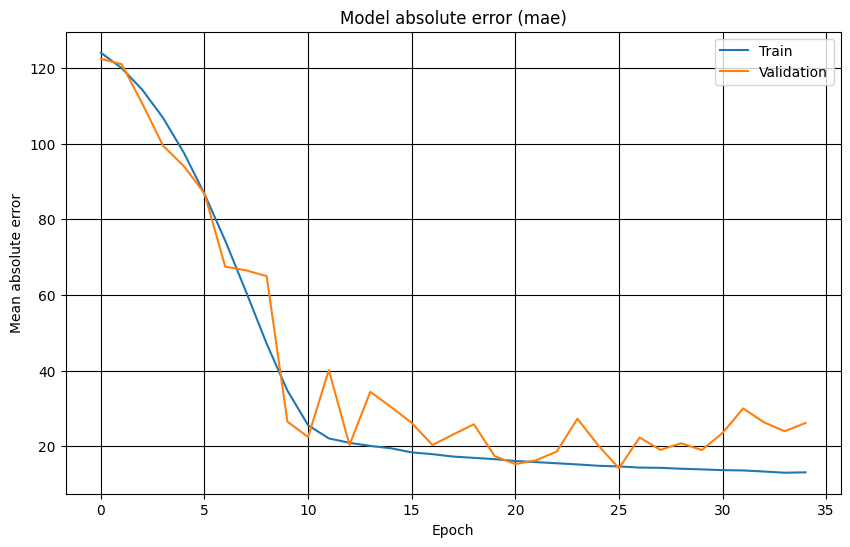

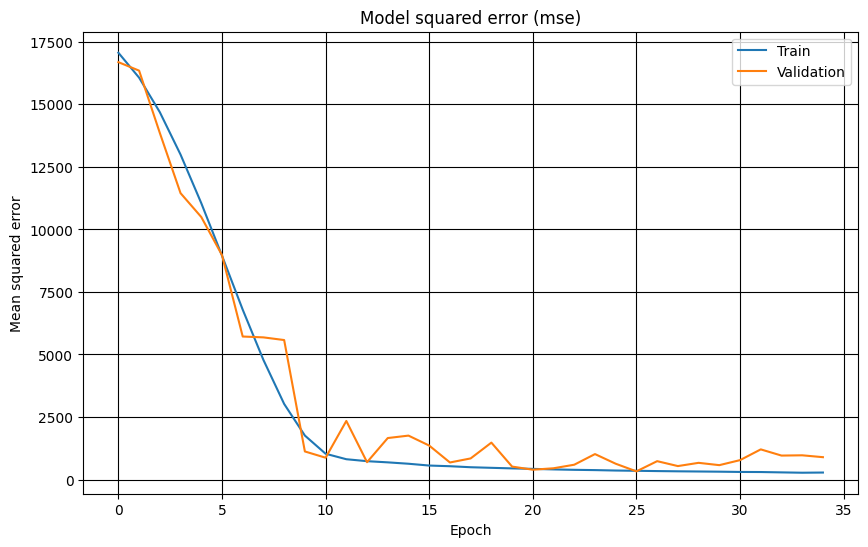

In [ ]:
history_data_vgg = pd.read_csv('/content/drive/MyDrive/AI_project/Models/vgg_baseline_log.csv')
fig = create_mae_figure(history_data_vgg)
fig.savefig('/content/drive/MyDrive/AI_project/Models/vgg_baseline_mae_plot.png')

fig = create_mse_figure(history_data_vgg)
fig.savefig('/content/drive/MyDrive/AI_project/Models/vgg_baseline_mse_plot.png')

Evaluating the baseline model with test set:

In [ ]:
vgg_baseline_test_results = vgg_model.evaluate(test_vgg_baseline, verbose=1)



119/119 [==============================] - 1700s 14s/step - loss: 346.2819 - mae: 14.5558


## Improved model:

This model maintains the fundamental structure of the baseline model but includes enhancements such as image augmentations, the utilization of the Adam optimizer, and the integration of a single dropout layer.

In [ ]:
def create_vgg_model_improved():
  inputs = tf.keras.Input(shape=(224,224,3))
  #1

  out =  tf.keras.layers.Conv2D(filters=20, kernel_size=(3,3), padding='same')(inputs)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out =  tf.keras.layers.Conv2D(filters=20, kernel_size=(3,3), padding='same')(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out =  tf.keras.layers.Conv2D(filters=20, kernel_size=(3,3), padding='same')(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out = tf.keras.layers.MaxPool2D()(out)

  #2

  out = tf.keras.layers.Conv2D(filters=40, kernel_size=(3,3), padding='same')(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out =  tf.keras.layers.Conv2D(filters=40, kernel_size=(3,3), padding='same')(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out =  tf.keras.layers.Conv2D(filters=40, kernel_size=(3,3), padding='same')(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out = tf.keras.layers.MaxPool2D()(out)

  #3
  out =  tf.keras.layers.Conv2D(filters=60, kernel_size=(3,3))(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  #4
  out =  tf.keras.layers.Conv2D(filters=40, kernel_size=(1,1))(out)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  #5
  out =  tf.keras.layers.Conv2D(filters=20, kernel_size=(1,1))(out) # og kernel_size=(3,3)
  out = tf.keras.layers.BatchNormalization()(out)
  out = tf.keras.layers.Activation('relu')(out)

  out = tf.keras.layers.GlobalAveragePooling2D()(out)
  out = tf.keras.layers.Dropout(0.25)(out) # adding droput

  result = tf.keras.layers.Dense(1, activation='linear')(out)
  model = tf.keras.Model(inputs=inputs, outputs=result)
  model.compile(optimizer='Adam', loss='mse', metrics=['mae']) # adding adam

  return model

In [ ]:
vgg_model_improved = create_vgg_model_improved()
vgg_model_improved.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d_18 (Conv2D)          (None, 224, 224, 20)      560       
                                                                 
 batch_normalization_18 (Ba  (None, 224, 224, 20)      80        
 tchNormalization)                                               
                                                                 
 activation_18 (Activation)  (None, 224, 224, 20)      0         
                                                                 
 conv2d_19 (Conv2D)          (None, 224, 224, 20)      3620      
                                                                 
 batch_normalization_19 (Ba  (None, 224, 224, 20)      80        
 tchNormalization)                                         

In [ ]:
train_g2, val_g2, test_g2 = datagenerators(False)
train_vgg_improved, val_vgg_improved, test_vgg_improved,pred_vgg_improved = dataloaders(False, df_train, df_val, df_test, train_g2, val_g2, test_g2)

Found 7061 validated image filenames.
Found 1766 validated image filenames.
Found 3784 validated image filenames.
Found 3784 validated image filenames.


In [ ]:
vgg_model_improved.load_weights('/content/drive/MyDrive/AI_project/Models/vgg_improved.h5')

In [ ]:
train_model(vgg_model_improved, train_vgg_improved, val_vgg_improved, baseline=False)

Epoch 1/50
221/221 [==============================] - 4350s 20s/step - loss: 701.5699 - mae: 21.0248 - val_loss: 1231.9512 - val_mae: 29.7659 - lr: 0.0010
Epoch 2/50
221/221 [==============================] - 416s 2s/step - loss: 689.5617 - mae: 20.9296 - val_loss: 422.1511 - val_mae: 15.7785 - lr: 0.0010
Epoch 3/50
221/221 [==============================] - 414s 2s/step - loss: 690.2452 - mae: 20.8248 - val_loss: 433.9561 - val_mae: 16.6080 - lr: 0.0010
Epoch 4/50
221/221 [==============================] - 412s 2s/step - loss: 710.1591 - mae: 20.9165 - val_loss: 497.7546 - val_mae: 17.7585 - lr: 0.0010
Epoch 5/50
221/221 [==============================] - 416s 2s/step - loss: 697.8198 - mae: 20.8339 - val_loss: 712.3741 - val_mae: 22.2178 - lr: 0.0010
Epoch 6/50
221/221 [==============================] - 433s 2s/step - loss: 679.1608 - mae: 20.6785 - val_loss: 385.1879 - val_mae: 15.5546 - lr: 0.0010
Epoch 7/50
221/221 [==============================] - 416s 2s/step - loss: 665.2738 -

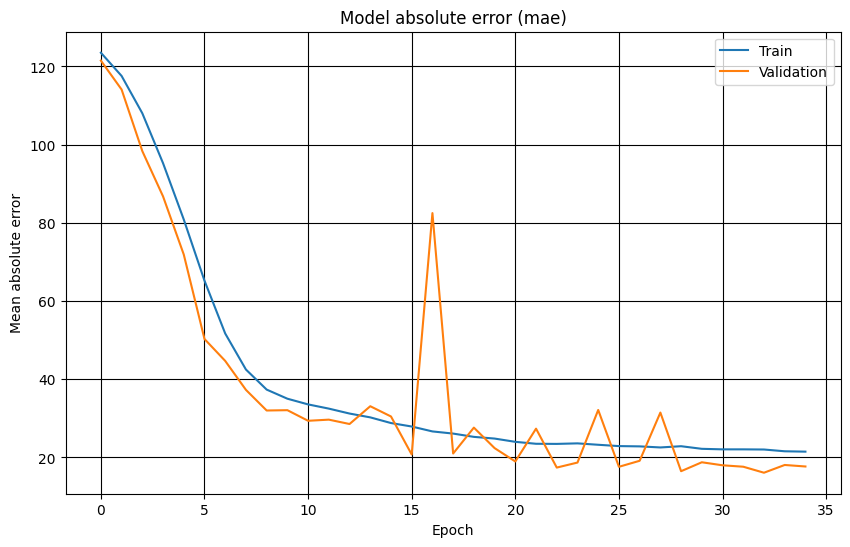

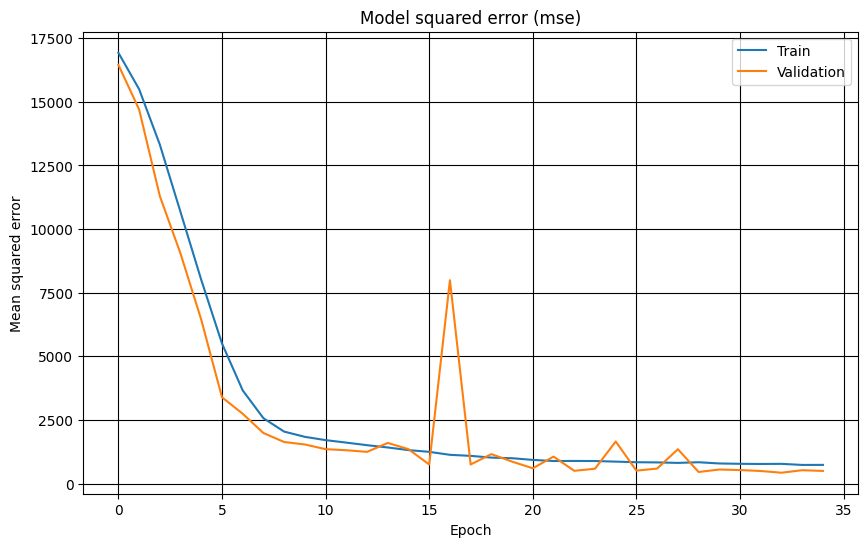

In [ ]:
history_data_improved = pd.read_csv('/content/drive/MyDrive/AI_project/Models/vgg_improved_log.csv')
fig = create_mae_figure(history_data_improved)
fig.savefig('/content/drive/MyDrive/AI_project/Models/vgg_improved_mae_plot.png')

fig = create_mse_figure(history_data_improved)
fig.savefig('/content/drive/MyDrive/AI_project/Models/vgg_improved_mse_plot.png')


Evaluating the baseline model with test set:

In [ ]:
vgg_improved_test_results = vgg_model_improved.evaluate(test_vgg_improved, verbose=1)

119/119 [==============================] - 135s 1s/step - loss: 468.6163 - mae: 16.7965


## Model evaluation

### Using bootstrapping to compare model performance: 

Bootstrapping is applied to evaluate and compare the performance of the baseline and improved models, using Mean Absolute Error and Mean Squared Error

In [ ]:
#predictions:
#pred_vgg_baseline.reset()
#pred_vgg_improved.reset()
vgg_baseline_predictions = vgg_model.predict(test_vgg_baseline)
vgg_improved_predictions = vgg_model_improved.predict(test_vgg_improved)



119/119 [==============================] - 145s 1s/step


In [ ]:
np.random.seed(50)
alpha = 95
n_iterations = 10000

mse = []
mae= []

true_labels = np.array(df_test['boneage'].tolist())
vgg_baseline_predictions = np.array(vgg_baseline_predictions)
vgg_improved_predictions = np.array(vgg_improved_predictions)
inds = np.arange(len(true_labels))


for _ in tqdm(range(n_iterations), total=n_iterations, desc="Bootstrapping"):
    ind = np.random.choice(inds, 3000, replace=True)

    mse_base = mean_squared_error(true_labels[ind], vgg_baseline_predictions[ind])
    mse_imp = mean_squared_error(true_labels[ind], vgg_improved_predictions[ind])
    mse.append((mse_base, mse_imp))

    mae_base = mean_absolute_error(true_labels[ind], vgg_baseline_predictions[ind])
    mae_imp = mean_absolute_error(true_labels[ind], vgg_improved_predictions[ind])
    mae.append((mae_base, mae_imp))


mse_base = mean_squared_error(true_labels, vgg_baseline_predictions)
mse_imp = mean_squared_error(true_labels, vgg_improved_predictions)
mse_diff_emp  = mse_imp - mse_base

mae_base = mean_absolute_error(true_labels, vgg_baseline_predictions)
mae_imp = mean_absolute_error(true_labels, vgg_improved_predictions)
mae_diff_emp  = mae_imp - mae_base

# We store bootstrap distribution here as numpy arrays for a more convenient indexing
mae = np.array(mae)
mse = np.array(mse)

mae_base_ci_l = np.percentile(mae[:, 0], (100 - alpha) // 2)
mae_base_ci_h = np.percentile(mae[:, 0], alpha + (100 - alpha) // 2)
mae_imp_ci_l = np.percentile(mae[:, 1], (100 - alpha) // 2)
mae_imp_ci_h = np.percentile(mae[:, 1], alpha + (100 - alpha) // 2)

mse_base_ci_l = np.percentile(mse[:, 0], (100 - alpha) // 2)
mse_base_ci_h = np.percentile(mse[:, 0], alpha + (100 - alpha) // 2)
mse_imp_ci_l = np.percentile(mse[:, 1], (100 - alpha) // 2)
mse_imp_ci_h = np.percentile(mse[:, 1], alpha + (100 - alpha) // 2)

Bootstrapping: 100%|██████████| 10000/10000 [00:09<00:00, 1018.50it/s]


VGG Baseline [Mae] 45.79 [44.54-47.00]
VGG Improved [Mae] 41.87 [40.71-42.95]
P-value: 1.0001


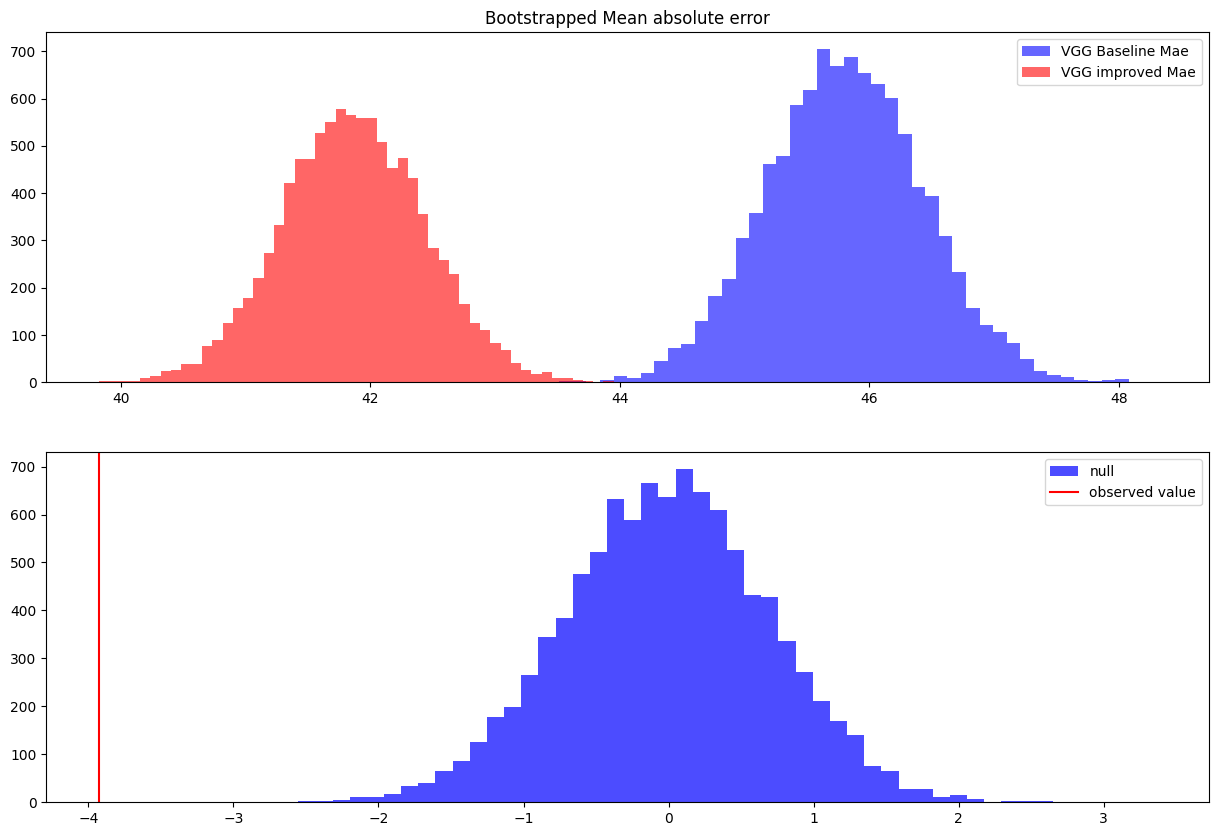

In [ ]:
fig, ax = plt.subplots(2, figsize=(15, 10))
ax[0].set_title("Bootstrapped Mean absolute error")
ax[0].hist(mae[:, 0], bins=50, alpha=0.6, label='VGG Baseline Mae', color='b')
ax[0].hist(mae[:, 1], bins=50, alpha=0.6, label='VGG improved Mae', color='r')
ax[0].set
ax[0].legend()

print(f"VGG Baseline [Mae] {mae_base:.2f} [{mae_base_ci_l:.2f}-{mae_base_ci_h:.2f}]")
print(f"VGG Improved [Mae] {mae_imp:.2f} [{mae_imp_ci_l:.2f}-{mae_imp_ci_h:.2f}]")

null_distribution = mae[:, 1] - mae[:, 0] - mae_diff_emp
ax[1].hist(null_distribution, bins=50, color='blue', alpha=0.7, label="null")
ax[1].axvline(mae_diff_emp, color='red', label="observed value")
ax[1].legend()

p_mae = (1 + np.sum(null_distribution >= mae_diff_emp)) / mae.shape[0]
print(f"P-value: {p_mae:.4f}")
plt.show()

VGG Baseline [Mse] 3261.40 [3097.24-3415.70]
VGG Improved [Mse] 2729.17 [2593.19-2856.78]
P-value: 1.0001


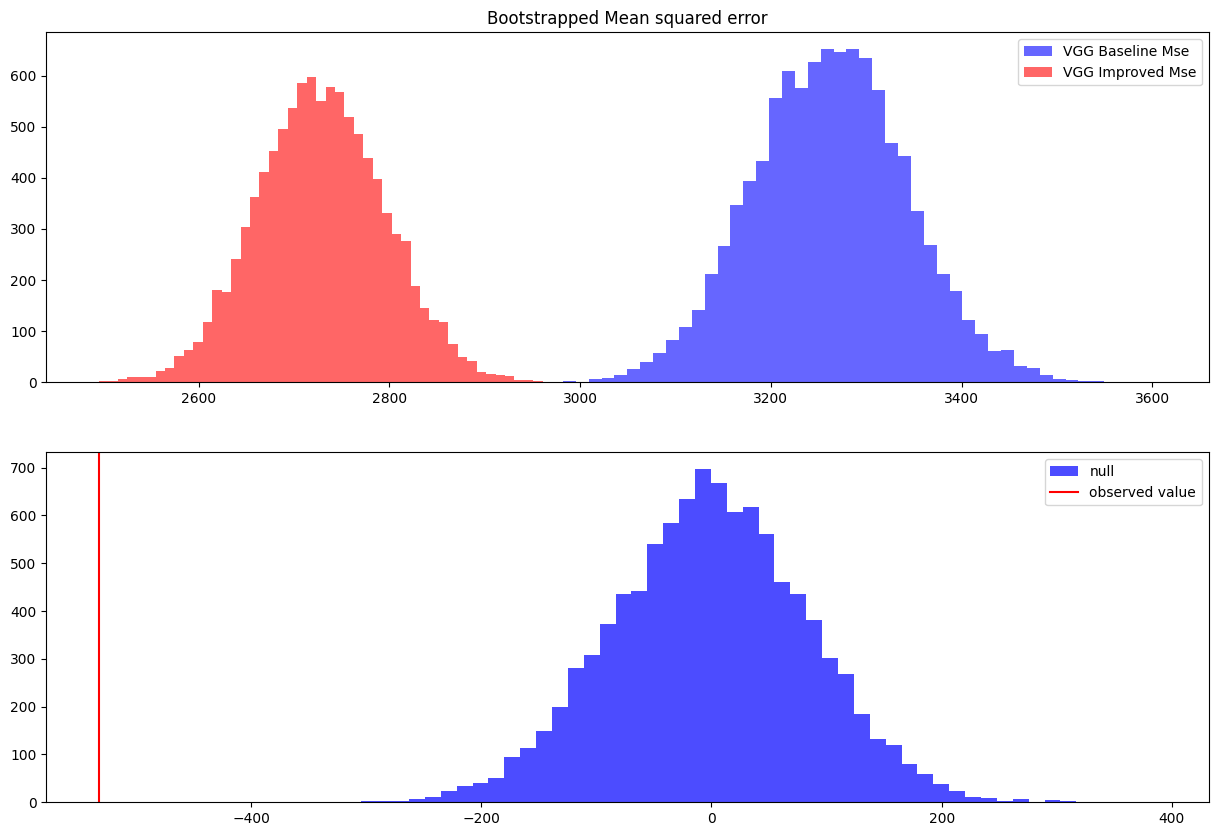

In [ ]:
fig, ax = plt.subplots(2, figsize=(15, 10))
ax[0].set_title("Bootstrapped Mean squared error")
ax[0].hist(mse[:, 0], bins=50, alpha=0.6, label='VGG Baseline Mse', color='b')
ax[0].hist(mse[:, 1], bins=50, alpha=0.6, label='VGG Improved Mse', color='r')
ax[0].set
ax[0].legend()

print(f"VGG Baseline [Mse] {mse_base:.2f} [{mse_base_ci_l:.2f}-{mse_base_ci_h:.2f}]")
print(f"VGG Improved [Mse] {mse_imp:.2f} [{mse_imp_ci_l:.2f}-{mse_imp_ci_h:.2f}]")

null_distribution = mse[:, 1] - mse[:, 0] - mse_diff_emp
ax[1].hist(null_distribution, bins=50, color='blue', alpha=0.7, label="null")
ax[1].axvline(mse_diff_emp, color='red', label="observed value")
ax[1].legend()

p_mse = (1 + np.sum(null_distribution >= mse_diff_emp)) / mse.shape[0]
print(f"P-value: {p_mse:.4f}")
plt.show()

## Conclusions 

After bootstrapping, we can see that the improved model with image augmentations performed significantly better than the baseline model.

## Improved model without augmentations

Same improved model but this time without any image augmentations:

In [ ]:
vgg_model_improved_noaug = create_vgg_model_improved()

In [ ]:
vgg_model_improved_noaug.load_weights('/content/drive/MyDrive/AI_project/Models/vgg_improved_no_augments.h5')


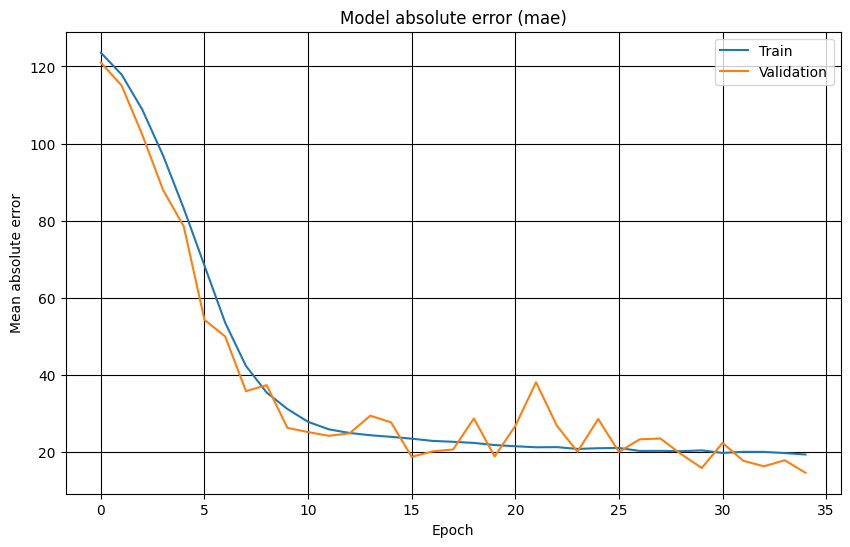

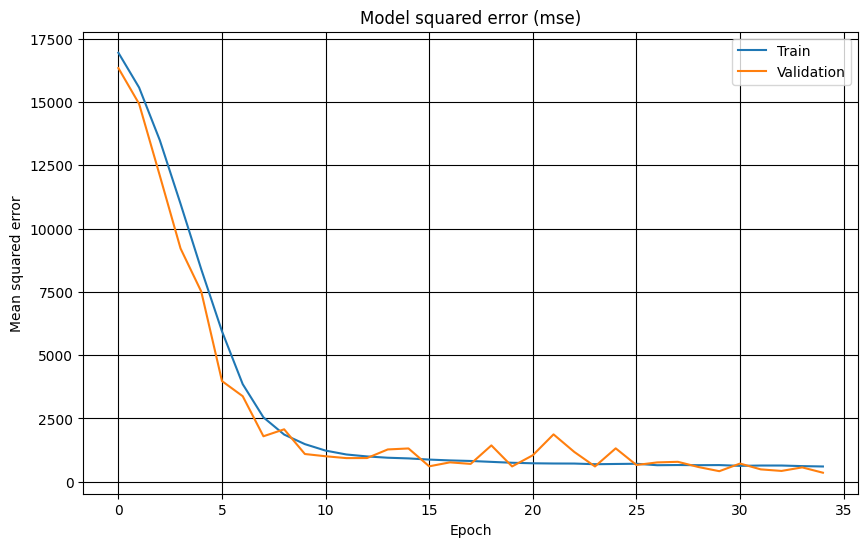

In [ ]:
history_data_improved = pd.read_csv('/content/drive/MyDrive/AI_project/Models/vgg_improved_no_augments_log.csv')
fig = create_mae_figure(history_data_improved)
fig.savefig('/content/drive/MyDrive/AI_project/Models/vgg_improved_noaug_mae_plot.png')

fig = create_mse_figure(history_data_improved)
fig.savefig('/content/drive/MyDrive/AI_project/Models/vgg_improved_noaug_mse_plot.png')

In [ ]:
vgg_model_improved_noaug_results = vgg_model_improved_noaug.evaluate(test_vgg_improved, verbose=1)

119/119 [==============================] - 1569s 13s/step - loss: 368.1514 - mae: 15.1263


#### Bootstrapping the baseline against the non-augmented improved model

In [ ]:
vgg_model_improved_noaug_predict = vgg_model_improved_noaug.predict(test_vgg_improved)

Bootstrapping: 100%|██████████| 10000/10000 [00:10<00:00, 917.27it/s]


VGG Baseline [Mae] 45.79 [44.54-47.00]
VGG Improved [Mae] 45.15 [43.84-46.33]
P-value: 0.7947


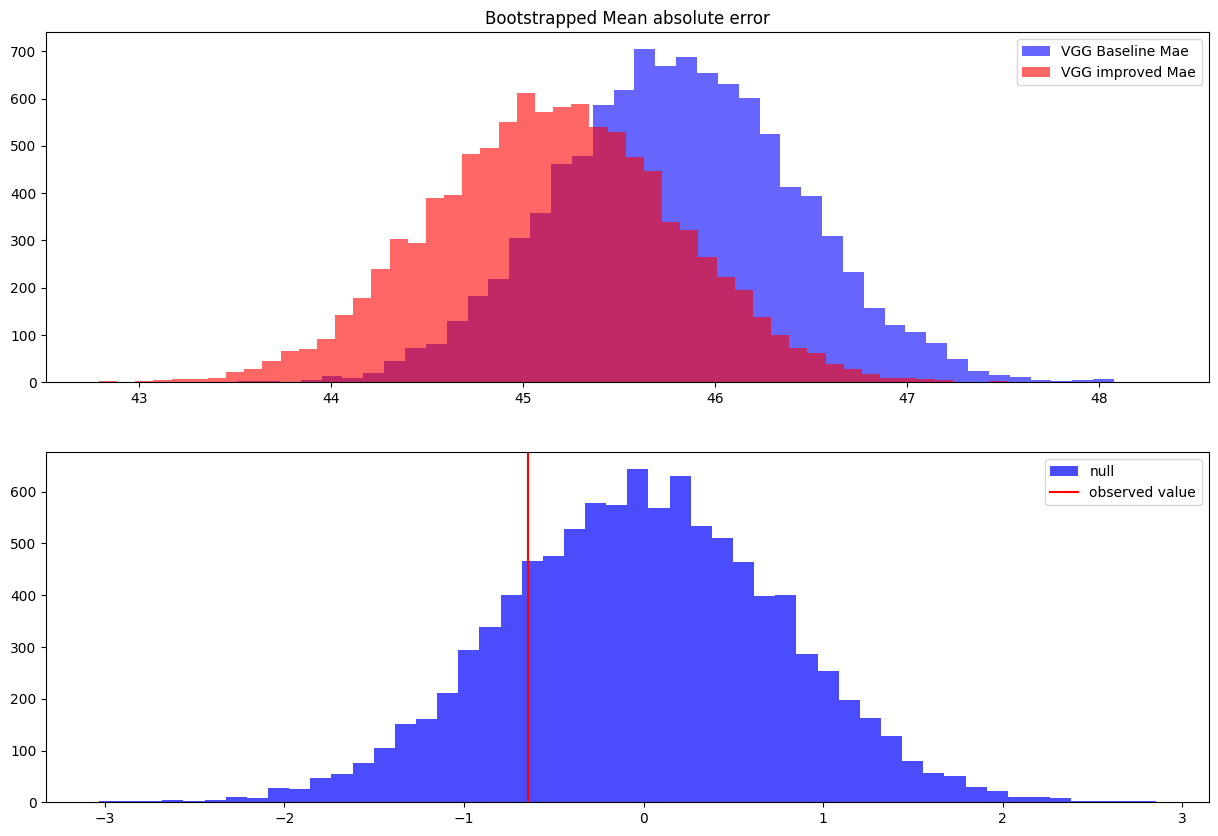

VGG Baseline [Mse] 3261.40 [3097.24-3415.70]
VGG Improved [Mse] 3246.04 [3074.24-3403.96]
P-value: 0.5621


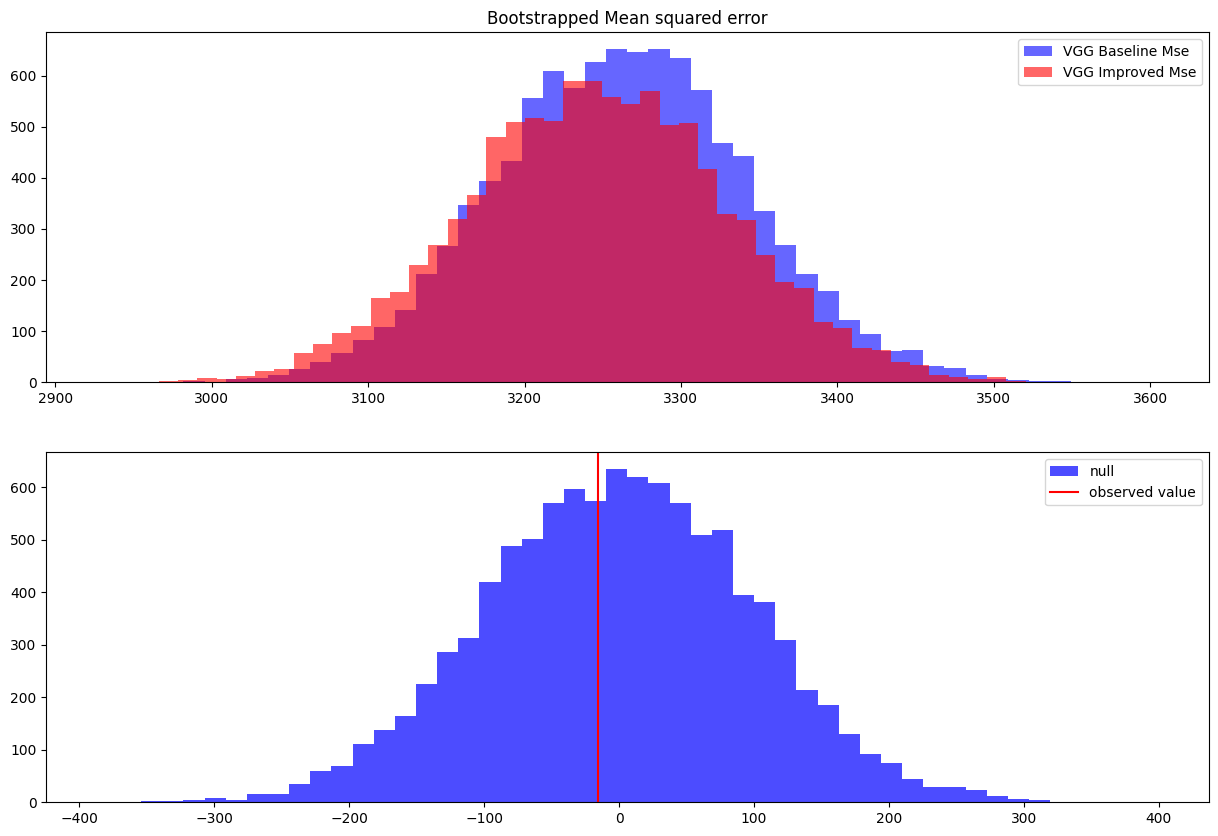

In [ ]:
np.random.seed(50)
alpha = 95
n_iterations = 10000

mse = []
mae= []

true_labels = np.array(test_vgg_baseline.labels)
vgg_baseline_predictions = np.array(vgg_baseline_predictions)
vgg_model_improved_noaug_predictions = np.array(vgg_model_improved_noaug_predict)
inds = np.arange(len(true_labels))


for _ in tqdm(range(n_iterations), total=n_iterations, desc="Bootstrapping"):
    ind = np.random.choice(inds, 3000, replace=True)

    mse_base = mean_squared_error(true_labels[ind], vgg_baseline_predictions[ind])
    mse_imp = mean_squared_error(true_labels[ind], vgg_model_improved_noaug_predictions[ind])
    mse.append((mse_base, mse_imp))

    mae_base = mean_absolute_error(true_labels[ind], vgg_baseline_predictions[ind])
    mae_imp = mean_absolute_error(true_labels[ind], vgg_model_improved_noaug_predictions[ind])
    mae.append((mae_base, mae_imp))


mse_base = mean_squared_error(true_labels, vgg_baseline_predictions)
mse_imp = mean_squared_error(true_labels, vgg_model_improved_noaug_predictions)
mse_diff_emp  = mse_imp - mse_base

mae_base = mean_absolute_error(true_labels, vgg_baseline_predictions)
mae_imp = mean_absolute_error(true_labels, vgg_model_improved_noaug_predictions)
mae_diff_emp  = mae_imp - mae_base

# We store bootstrap distribution here as numpy arrays for a more convenient indexing
mae = np.array(mae)
mse = np.array(mse)

mae_base_ci_l = np.percentile(mae[:, 0], (100 - alpha) // 2)
mae_base_ci_h = np.percentile(mae[:, 0], alpha + (100 - alpha) // 2)
mae_imp_ci_l = np.percentile(mae[:, 1], (100 - alpha) // 2)
mae_imp_ci_h = np.percentile(mae[:, 1], alpha + (100 - alpha) // 2)

mse_base_ci_l = np.percentile(mse[:, 0], (100 - alpha) // 2)
mse_base_ci_h = np.percentile(mse[:, 0], alpha + (100 - alpha) // 2)
mse_imp_ci_l = np.percentile(mse[:, 1], (100 - alpha) // 2)
mse_imp_ci_h = np.percentile(mse[:, 1], alpha + (100 - alpha) // 2)

fig, ax = plt.subplots(2, figsize=(15, 10))
ax[0].set_title("Bootstrapped Mean absolute error")
ax[0].hist(mae[:, 0], bins=50, alpha=0.6, label='VGG Baseline Mae', color='b')
ax[0].hist(mae[:, 1], bins=50, alpha=0.6, label='VGG improved Mae', color='r')
ax[0].set
ax[0].legend()

print(f"VGG Baseline [Mae] {mae_base:.2f} [{mae_base_ci_l:.2f}-{mae_base_ci_h:.2f}]")
print(f"VGG Improved [Mae] {mae_imp:.2f} [{mae_imp_ci_l:.2f}-{mae_imp_ci_h:.2f}]")

null_distribution = mae[:, 1] - mae[:, 0] - mae_diff_emp
ax[1].hist(null_distribution, bins=50, color='blue', alpha=0.7, label="null")
ax[1].axvline(mae_diff_emp, color='red', label="observed value")
ax[1].legend()

p_mae = (1 + np.sum(null_distribution >= mae_diff_emp)) / mae.shape[0]
print(f"P-value: {p_mae:.4f}")
plt.show()
fig, ax = plt.subplots(2, figsize=(15, 10))
ax[0].set_title("Bootstrapped Mean squared error")
ax[0].hist(mse[:, 0], bins=50, alpha=0.6, label='VGG Baseline Mse', color='b')
ax[0].hist(mse[:, 1], bins=50, alpha=0.6, label='VGG Improved Mse', color='r')
ax[0].set
ax[0].legend()

print(f"VGG Baseline [Mse] {mse_base:.2f} [{mse_base_ci_l:.2f}-{mse_base_ci_h:.2f}]")
print(f"VGG Improved [Mse] {mse_imp:.2f} [{mse_imp_ci_l:.2f}-{mse_imp_ci_h:.2f}]")

null_distribution = mse[:, 1] - mse[:, 0] - mse_diff_emp
ax[1].hist(null_distribution, bins=50, color='blue', alpha=0.7, label="null")
ax[1].axvline(mse_diff_emp, color='red', label="observed value")
ax[1].legend()

p_mse = (1 + np.sum(null_distribution >= mse_diff_emp)) / mse.shape[0]
print(f"P-value: {p_mse:.4f}")
plt.show()

## Conclusion:

Image augmentation clearly improved the test error. Without image augmentation there were no statistical significant difference between the improved and baseline model. These results indicated that adding image augmentations significantly enhances the model’s ability to generalize to unseen data, thereby enhancing its overall performance.


## Supplementary model


### Resnet50:

Resnet50  with pre-trained ImageNet weights

In [ ]:
train_g, val_g, test_g = datagenerators(False)
train, val, test = dataloaders(False, df_train, df_val, df_test, train_g, val_g, test_g)


Found 7061 validated image filenames.
Found 1766 validated image filenames.
Found 3784 validated image filenames.


In [ ]:
# Create resnet50 with added linear output layer to make it suitable for regression

resnet_part = ResNet50(input_shape=(256,256,3), weights='imagenet', include_top=False)
resnet_part.trainable = False

# build model:
inputs = tf.keras.Input(shape=(256,256,3))
x = preprocess_input(inputs)
x=resnet_part(x, training =False)

# Add dropout and globalaveragepooling
#x = Dropout(0.1)(x)    # was 0.2
x = GlobalAveragePooling2D()(x)

# Add linear output layer for regression task
result = Dense(1, activation='linear')(x)
model = tf.keras.Model(inputs=inputs, outputs=result)
model.summary(show_trainable=True)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])


94765736/94765736 [==============================] - 1s 0us/step
Model: "model"
____________________________________________________________________________
 Layer (type)                Output Shape              Param #   Trainable  
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         Y          
                                                                            
 tf.__operators__.getitem (  (None, 256, 256, 3)       0         Y          
 SlicingOpLambda)                                                           
                                                                            
 tf.nn.bias_add (TFOpLambda  (None, 256, 256, 3)       0         Y          
 )                                                                          
                                                                            
 resnet50 (Functional)       (None, 8, 8, 2048)        2358771   N          
                                                       2                 

In [ ]:
#model.load_weights('/content/drive/MyDrive/AI_project/Models/resnet50.h5')
#model = tf.keras.models.load_model('/content/drive/MyDrive/AI_project/Models/pretrained3_resnet50.keras')

ValueError: ignored

In [ ]:

checkpoint_filepath = '/content/drive/MyDrive/AI_project/Models/resnet50_12_pretrained.h5'
log_file_path = '/content/drive/MyDrive/AI_project/Models/resnet50_log_12_pretrained.csv'

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
      filepath=checkpoint_filepath,
      save_weights_only=True,
      monitor='val_loss',
      mode='min',
      save_best_only=True)

csv_logger = tf.keras.callbacks.CSVLogger(log_file_path, separator=',', append=False)
model.fit(train, validation_data=val, epochs=12,
                  callbacks=[ model_checkpoint_callback, csv_logger] )
#model.save('/content/drive/MyDrive/AI_project/Models/resnet50_10_pretrained.keras')

Epoch 1/12
221/221 [==============================] - 3578s 16s/step - loss: 12961.6064 - mae: 105.6623 - val_loss: 8695.3174 - val_mae: 84.7030
Epoch 2/12
221/221 [==============================] - 2896s 13s/step - loss: 6072.2402 - mae: 68.7810 - val_loss: 4117.8545 - val_mae: 55.7070
Epoch 3/12
221/221 [==============================] - 2947s 13s/step - loss: 3051.0066 - mae: 47.3415 - val_loss: 2349.5513 - val_mae: 41.7829
Epoch 4/12
221/221 [==============================] - 2919s 13s/step - loss: 2001.5033 - mae: 37.9631 - val_loss: 1827.2438 - val_mae: 36.3497
Epoch 5/12
173/221 [======================>.......] - ETA: 8:35 - loss: 1743.8931 - mae: 34.8109

UnknownError: ignored

In [ ]:

#model = tf.keras.models.load_model('/content/drive/MyDrive/AI_project/Models/pretrained3_resnet50.keras')

In [ ]:
# Tune parameters
resnet_part.trainable = True
model.summary(show_trainable=True)
model.compile(optimizer=Adam(learning_rate = 1e-4),loss='mse', metrics=['mae'])

Model: "model_1"
____________________________________________________________________________
 Layer (type)                Output Shape              Param #   Trainable  
 input_4 (InputLayer)        [(None, 256, 256, 3)]     0         Y          
                                                                            
 tf.__operators__.getitem_1  (None, 256, 256, 3)       0         Y          
  (SlicingOpLambda)                                                         
                                                                            
 tf.nn.bias_add_1 (TFOpLamb  (None, 256, 256, 3)       0         Y          
 da)                                                                        
                                                                            
 resnet50 (Functional)       (None, 8, 8, 2048)        2358771   Y          
                                                       2                    
                                                           

In [ ]:
model.load_weights('/content/drive/MyDrive/AI_project/Models/resnet50_sec.h5')

In [ ]:
train_model(model, train, val, baseline=False)


FileExistsError: ignored